# PVGIS quickstart — hourly solar radiation (live)

The `pvgis` backend fetches solar-radiation / PV time series from the keyless
[JRC PVGIS 5.3](https://re.jrc.ec.europa.eu/pvg_tools/) REST API. No
credentials, no SDK. This notebook pulls one year of **hourly** radiation for a
single point (northern Italy) and inspects the returned `pandas.DataFrame`.

In [1]:
import tempfile

import matplotlib.pyplot as plt
from earthlens.earthlens import EarthLens

OUT = tempfile.mkdtemp()  # downloads also write a CSV here

## Download one year of `seriescalc`

`variables=["seriescalc"]` selects the hourly radiation tool. A single
`point=(lat, lon)` is one keyless GET; the `start` / `end` years bound the
window. `download()` returns the hourly table and writes it to `path` as CSV.

In [2]:
df = EarthLens(
    data_source="pvgis",
    variables=["seriescalc"],
    start="2020-01-01",
    end="2020-12-31",
    point=(45.0, 8.0),
    path=OUT,
).download(progress_bar=False)

print(df.shape)
df.head()

2026-06-26 20:44:59.745 | INFO     | earthlens.pvgis.backend:download:327 - PVGIS seriescalc: 8784 row(s) -> C:\Users\main\AppData\Local\Temp\tmpcbc8_jz0\pvgis_seriescalc.csv


2026-06-26 20:44:59.745 | INFO     | earthlens.pvgis.backend:download:328 - PVGIS (c) European Union, 2001-2024 — data from the JRC Photovoltaic Geographical Information System (PVGIS), https://re.jrc.ec.europa.eu/pvg_tools/. Free reuse with attribution.


(8784, 9)


,time,G(i),H_sun,T2m,WS10m,Int,lat,lon,product
0,2020-01-01 00:10:00,0.0,0.0,1.81,0.90,0.0,45.0,8.0,seriescalc
1,2020-01-01 01:10:00,0.0,0.0,1.26,0.83,0.0,45.0,8.0,seriescalc
2,2020-01-01 02:10:00,0.0,0.0,0.90,0.76,0.0,45.0,8.0,seriescalc
3,2020-01-01 03:10:00,0.0,0.0,0.69,0.69,0.0,45.0,8.0,seriescalc
4,2020-01-01 04:10:00,0.0,0.0,0.46,0.62,0.0,45.0,8.0,seriescalc


Each row is one hour. `G(i)` is global in-plane irradiance (W/m²), `T2m` the
air temperature (°C), `WS10m` the wind speed; `lat` / `lon` / `product` tag the
sampled point. The `time` column is a parsed `datetime64`.

In [3]:
df.dtypes

time       datetime64[us]
G(i)              float64
H_sun             float64
T2m               float64
WS10m             float64
Int               float64
lat               float64
lon               float64
product               str
dtype: object

## Plot a few days of irradiance

A short window shows the diurnal cycle of `G(i)`.

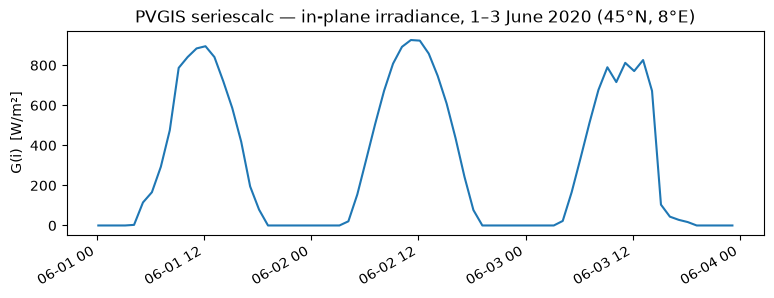

In [4]:
window = df[df["time"] < "2020-06-04"]
window = window[window["time"] >= "2020-06-01"]

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(window["time"], window["G(i)"])
ax.set_ylabel("G(i)  [W/m²]")
ax.set_title("PVGIS seriescalc — in-plane irradiance, 1–3 June 2020 (45°N, 8°E)")
fig.autofmt_xdate()
plt.show()

## Takeaway

One keyless call returns a tidy hourly `DataFrame` you can resample or plot
directly. PVGIS already returns the resolved hourly series, so the facade
rejects `aggregate=`; use pandas (`df.set_index("time").resample("1D").mean()`)
for a coarser cadence.